# INFO-F-422 - Statistical Foundations of Machine Learning

**Teaching assistants:**  
Gian Marco Paldino - gian.marco.paldino@ulb.be  
Cédric Simar - cedric.simar@ulb.be  
Pascal Tribel - pascal.tribel@ulb.be

**Reference**: *"Statistical Foundations of Machine Learning: the handbook"*  
by **Gianluca Bontempi**, Machine Learning Group, Computer Science Department, ULB

---

# Practical 4: Neural Networks for Regression

## 1. Introduction to Neural Networks

This part of the introduction summarizes the key theoretical concepts for **Neural Networks for Regression**, building on Chapter 8 of the handbook (pp. 189–199).


### 1.1. Data Preprocessing for Neural Networks

#### 1.1.1 Normalization and Standardization

**Motivation**:
Gradient-based optimization of neural networks often becomes unstable if different features vary widely in scale. Hence, **Sec. 8.1** of the handbook (and earlier practicals) reiterate that scaling inputs to zero mean and unit variance—or to a small bounded range—is essential. This ensures the gradients have more balanced magnitudes across parameters, which helps the optimizer converge more reliably.

**Typical Steps**:
1. Compute the empirical mean and standard deviation of each input dimension:
   $$
   \mu_j = \frac{1}{N} \sum_{i=1}^N x_{ij}, \quad
   \sigma_j = \sqrt{\frac{1}{N}\sum_{i=1}^N (x_{ij}-\mu_j)^2}.
   $$
2. Transform (standardise) the data as
   $$
   x_{ij}^{(std)} = \frac{x_{ij} - \mu_j}{\sigma_j}.
   $$
3. Use the same $\mu_j$ and $\sigma_j$ for the validation and test sets to maintain consistency.

#### 1.1.2 Input Data Shaping
- **For MLPs**: Usually arrange training data into a matrix of shape $(\text{batch}, n)$, where $n$ is the number of input features.
- **For CNNs**: Reshape data into a 4D tensor of shape $(\text{batch}, \text{channels}, \text{height}, \text{width})$. Convolutional layers exploit the spatial dimensions for images or other grid-like inputs.


In [1]:
# Example in Python-like pseudocode:
import torch

# Suppose X_train is shape (N, n) for an MLP:
N, n = 1000, 10
X_train = torch.randn(N, n)
X_val = torch.randn(N//5, n)
X_test = torch.randn(N//5, n)

mean = X_train.mean(dim=0)
std  = X_train.std(dim=0)

X_train = (X_train - mean) / std
X_val   = (X_val - mean) / std
X_test  = (X_test - mean) / std

# For CNN input, if needed:
H, W = 28, 28  # e.g., image dimension
# Reshape to (N, 1, H, W) for single-channel images:
X_train_cnn = X_train.view(N, 1, H, W)
X_val_cnn   = X_val.view(N//5, 1, H, W)
X_test_cnn  = X_test.view(N//5, 1, H, W)

RuntimeError: shape '[1000, 1, 28, 28]' is invalid for input of size 10000

### 1.2 Feed-Forward Neural Networks (MLPs)

#### 1.2.1 Architecture and Notation

An MLP (or feed-forward network) with $L$ layers (including hidden and output layers) maps an input vector $\mathbf{x}\in\mathbb{R}^n$ to an output (for regression, typically $\hat{y}\in\mathbb{R}$ or $\mathbb{R}^m$) through successive affine transformations and nonlinear activations. In the notation of **Eqs. $(8.1.2)$–$(8.1.5)$**:

1. **Layer 1**:
   $$
   A^{(1)} = Z^{(0)} W^{(1)} + b^{(1)},\quad Z^{(1)} = g^{(1)}(A^{(1)}),
  $$
   where $Z^{(0)} = \mathbf{x}$ is the input and $W^{(1)}$ is an $(n \times h_1)$ weight matrix if the first hidden layer has $h_1$ units.

2. **Layer 2** (or subsequent hidden layers):
   $$
   A^{(2)} = Z^{(1)} W^{(2)} + b^{(2)},\quad Z^{(2)} = g^{(2)}(A^{(2)}),
  $$
   continuing similarly up to layer $L-1$.

3. **Output Layer** ($l=L$):
   For regression with a linear output,
   $$
   A^{(L)} = Z^{(L-1)} W^{(L)} + b^{(L)},\quad Z^{(L)} = A^{(L)}.
  $$
   If the output dimension is 1, $W^{(L)}$ is $(h_{L-1} \times 1)$. For vector outputs, adjust accordingly.

#### 1.2.2 Activation Functions

Nonlinearities $g^{(l)}(\cdot)$ are critical. Common examples in the course:
- **Sigmoid**: $\sigma(z)=1/(1+e^{-z})$, which saturates for large $|z|$.
- **Tanh**: $\tanh(z)\in(-1,1)$, similar saturation behavior.
- **ReLU**: $\max(0,z)$, which alleviates vanishing gradients on the positive side and is widely used in deep networks.

Without a nonlinear $g^{(l)}$, the stacked linear transformations collapse to an effective single linear mapping. Nonlinearity ensures the network can approximate complex functions (Universal Approximation property).

### 1.3 Cost function and matrix-based Back-Propagation

#### 1.3.1 Sum of Squared Errors (SSE)

For regression tasks, the *empirical sum of squared errors*:
$$
\mathrm{SSE}_{\mathrm{emp}}(\alpha_N) = \sum_{i=1}^N (y_i - \hat{y}(x_i))^2,
\]
where $\hat{y}(x_i)$ is the network’s prediction for input $x_i$, and $y_i$ is the true target. The parameter vector $\alpha_N$ includes $\{W^{(l)}, b^{(l)}\}$ for $l=1,\ldots,L$.

#### 1.3.2 Gradient Descent Update

Using the notation from **Algorithm 2 (p. 194)**, we iteratively update each parameter in the direction that reduces the SSE cost:
$$
\alpha_N(k+1) = \alpha_N(k) - \eta\, \frac{\partial\,\mathrm{SSE}_{\mathrm{emp}}}{\partial\,\alpha_N}(k),
\]
where $\eta$ is the learning rate.

#### 1.3.3 Back-Propagation (Algorithm 2)

Back-propagation is the application of the chain rule to compute $\nabla \mathrm{SSE}_{\mathrm{emp}}$ with respect to each weight matrix $W^{(l)}$ and bias $b^{(l)}$.

1. **Output-Layer Delta**:
   $$
   \delta^{(L)} = \frac{\partial\,\mathrm{SSE}_{\mathrm{emp}}}{\partial\,A^{(L)}} \odot g'^{(L)}(A^{(L)}).
  $$
   - In linear output regression, $g'^{(L)}(\cdot) = 1$, and the cost derivative is $\delta^{(L)} = (\hat{y}-y).$

2. **Backward Recursion**:
   $$
   \delta^{(l)} = \bigl(W^{(l+1)} \delta^{(l+1)}\bigr) \odot g'^{(l)}(A^{(l)}), \quad l = L-1,\ldots,1.
  $$
   This “error” $\delta^{(l)}$ is used to compute partial derivatives for $W^{(l)}$ and $b^{(l)}$.

3. **Gradient w.r.t. Weights**:
   $$
   \frac{\partial\,\mathrm{SSE}_{\mathrm{emp}}}{\partial\,W^{(l)}} = (Z^{(l-1)})^\top \,\delta^{(l)},\quad
   \frac{\partial\,\mathrm{SSE}_{\mathrm{emp}}}{\partial\,b^{(l)}} = \sum_{i=1}^{N} \delta^{(l)}_i.
  $$
   using the matrix-based form.


In [ ]:
# Illustration in Python (symbolic style)
import torch
import torch.nn as nn

class Simple2LayerMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim=1):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.fc1(x)
        x = torch.relu(x)  # ReLU activation
        x = self.fc2(x)    # linear output for regression
        return x

# Instantiate the network and define SSE-like loss
model = Simple2LayerMLP(input_dim=10, hidden_dim=15, output_dim=1)
criterion = nn.MSELoss(reduction='sum')  # SSE (sum of squared errors)
eta = 1e-2

# Dummy data
X_sample = torch.randn(5, 10)
y_sample = torch.randn(5, 1)

y_pred = model(X_sample)
loss = criterion(y_pred, y_sample)

# Backpropagate
loss.backward()

# Gradient descent step
with torch.no_grad():
    for param in model.parameters():
        param -= eta * param.grad
        param.grad.zero_()


### 1.4 Convolutional Neural Networks (CNNs)

Though the practical focuses on regression, CNNs (p. 198–199) illustrate deep architectures that handle grid-structured data (e.g., images). Main ideas:
1. **Local Connectivity**: Each neuron in a convolutional layer only connects to a local patch of the input.
2. **Shared Weights**: A small kernel (filter) is “convolved” across the entire image or feature map.
3. **Translation Equivariance**: The same filter is applied at all spatial locations.

#### 1.4.1 Convolution Operation
A single 2D filter:
$$
y_{ij} = \sum_{m=1}^{k_h} \sum_{n=1}^{k_w} W_{mn} x_{(i + m - 1, j + n - 1)} + b,
$$
where $(k_h, k_w)$ is the kernel size. ReLU or another activation is then applied.

#### 1.4.2 Pooling Layers
Often, a **pooling** layer follows one or more convolutional layers to reduce the spatial resolution. For instance, **max pooling** with a $2\times2$ window and stride 2 halves the height and width.

### 1.5 Overfitting and Cross-Validation

#### 1.5.1 Overfitting Phenomenon

In the handbook’s example on **p. 197**, a network with 15 hidden units achieves extremely low training SSE but high test SSE, illustrating **overfitting**. Overfitting arises when a model fits training data “too well,” capturing noise rather than the underlying trend.

#### 1.5.2 Detection and Mitigation
- **Validation Set**: Split data into training and validation. Monitor the validation error (e.g., MSE). If it increases while training error decreases, the model is overfitting.
- **Cross-Validation**: Alternatively, use $k$-fold cross-validation.
- **Regularization**:
  - **Dropout**: Temporarily “drop” a fraction of hidden units during training.
  - **Weight Decay (L2)**: Penalizes large weights.
  - **Early Stopping**: Halt training when validation performance stops improving.

### 1.6 Practical Aspects: Model Saving and Loading in PyTorch

For safe and reproducible experiments, one typically needs to **save**:
1. **Model Weights (state_dict)**: The learned parameters $\{W^{(l)},b^{(l)}\}$.
2. **Optimizer State (if resuming)**: Internal states like momentum buffers in gradient-based optimizers.

A typical code pattern:

In [ ]:
import torch
import torch.optim as optim
import torch.nn as nn

model = Simple2LayerMLP(10, 15, 1)
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Training... then save checkpoint
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch': 10
}, "checkpoint.pth")

# Later, to resume
checkpoint = torch.load("checkpoint.pth")
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
start_epoch = checkpoint['epoch'] + 1

# For inference, only model_state_dict is strictly required.


### 1.7 Complete example of a CNN for Regression

Below is a more detailed illustration of an implementation of a CNN in PyTorch for regression highlighting many of the points presented above:


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset

# This CNN will perform a regression task (e.g., predicting a real-valued output from an image).
# We'll use two convolution layers (with 2x2 max pooling after each), then two fully-connected layers,
# include dropout with probability=0.25, and weight decay in the optimizer for regularization.

class SimpleCNNRegression(nn.Module):
    def __init__(self):
        super().__init__()
        
        # First convolution
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding=1)
        
        # Second convolution
        self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1)
        
        # After two 2x2 pools on a 28x28 input, the spatial dimension goes 28->14->7
        # => final feature map is 16 x 7 x 7 = 16*7*7 = 784
        self.fc1   = nn.Linear(16 * 7 * 7, 64)  
        self.fc2   = nn.Linear(64, 1)          # single output for regression
        
        # Dropout layer to help regularize the fully connected part
        self.dropout = nn.Dropout(p=0.25)
        
        # MaxPool layer (2x2) used after each convolution
        self.pool   = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        # First conv: conv1 -> ReLU -> pool => shape: (N, 8, 14, 14)
        x = self.conv1(x)        
        x = F.relu(x)
        x = self.pool(x)
        
        # Second conv: conv2 -> ReLU -> pool => shape: (N, 16, 7, 7)
        x = self.conv2(x)        
        x = F.relu(x)
        x = self.pool(x)
        
        # Flatten => shape: (N, 16*7*7 = 784)
        x = x.view(x.size(0), -1)
        
        # First fully connected => ReLU => Dropout => shape: (N, 64)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout(x)
        
        # Final fully connected => shape: (N, 1)
        x = self.fc2(x)
        return x

# We'll create some dummy data for regression:
# - Shape of X: (N, 1, 28, 28)
# - Shape of y: (N, 1) containing continuous values
N_train = 1000
N_val   = 200
X_train = torch.randn(N_train, 1, 28, 28)
y_train = torch.randn(N_train, 1)  # random continuous targets
X_val   = torch.randn(N_val, 1, 28, 28)
y_val   = torch.randn(N_val, 1)

# We'll wrap the data in TensorDatasets and DataLoaders for batching
train_dataset = TensorDataset(X_train, y_train)
val_dataset   = TensorDataset(X_val, y_val)
batch_size    = 50
train_loader  = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader    = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)

# Instantiate our CNN model
model = SimpleCNNRegression()

# We'll use MSELoss for this regression task
criterion = nn.MSELoss()

# We'll use Adam optimizer with weight decay for L2 regularization
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# Setup for training with early stopping
max_epochs         = 20
patience           = 3  # number of epochs with no improvement allowed
best_val_loss      = float('inf')
epochs_no_improve  = 0
best_model_path    = "best_model.pth"

for epoch in range(max_epochs):
    # Train mode: enables dropout, etc.
    model.train()
    running_train_loss = 0.0
    
    # Fetch mini-batches from the training loader
    for X_batch, y_batch in train_loader:
        # Zero the parameter gradients
        optimizer.zero_grad()
        
        # Forward pass -> compute predictions
        preds = model(X_batch)
        
        # Compute MSE loss for regression
        loss = criterion(preds, y_batch)
        
        # Backward pass -> compute gradients
        loss.backward()
        
        # Update parameters
        optimizer.step()
        
        running_train_loss += loss.item()
    
    # Compute average training loss for this epoch
    avg_train_loss = running_train_loss / len(train_loader)
    
    # Validation phase (disable dropout, etc.)
    model.eval()
    running_val_loss = 0.0
    
    with torch.no_grad():
        for Xv_batch, yv_batch in val_loader:
            # Forward pass on validation set
            val_preds = model(Xv_batch)
            val_loss = criterion(val_preds, yv_batch)
            running_val_loss += val_loss.item()
    
    avg_val_loss = running_val_loss / len(val_loader)
    
    print(f"Epoch [{epoch+1}/{max_epochs}]  "
          f"Train MSE: {avg_train_loss:.4f}  "
          f"Val MSE: {avg_val_loss:.4f}")
    
    # Early stopping check
    if avg_val_loss < best_val_loss:
        # If validation improves, update best_val_loss and reset patience counter
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        # Save current model as best
        torch.save(model.state_dict(), best_model_path)
        print("  Best model saved (improved validation MSE).")
    else:
        epochs_no_improve += 1
        # If no improvement for 'patience' epochs, stop
        if epochs_no_improve >= patience:
            print("Early stopping triggered (no improvement).")
            break

print("\nTraining complete. Loading best model for final checks.")
best_model = SimpleCNNRegression()
best_model.load_state_dict(torch.load(best_model_path))
best_model.eval()

# We can now evaluate 'best_model' on the validation set (or test set if we had one).
# For instance, a quick check of final validation MSE:
final_val_loss = 0.0
with torch.no_grad():
    for Xv_batch, yv_batch in val_loader:
        val_preds = best_model(Xv_batch)
        val_loss = criterion(val_preds, yv_batch)
        final_val_loss += val_loss.item()
print(f"Final validation MSE (best model): {final_val_loss / len(val_loader):.4f}")


---

## 2 Introduction to PyTorch tensors

PyTorch is a popular open-source deep learning framework, and **tensors** are its core data structure. In PyTorch, tensors are the central data abstraction – a specialized data structure very similar to arrays or matrices, used to represent data (inputs, outputs, model parameters) in deep learning models. Tensors are conceptually like NumPy’s multi-dimensional arrays, but with two key advantages: they can run on GPUs (for accelerated computing), and they support automatic differentiation (through PyTorch’s autograd engine) for computing gradients. These features make tensors fundamental for building and training neural networks.

In this introduction, we’ll explore PyTorch tensors from the ground up. We assume you are comfortable with Python and NumPy, but completely new to PyTorch. We’ll cover what tensors are and how they compare to NumPy arrays, how to create and manipulate them, basic operations, how PyTorch’s autograd works for automatic differentiation, and some additional important tensor functionalities like broadcasting, using GPUs, and in-place operations. Along the way, you’ll find hands-on code examples you can run and modify to solidify your understanding.

Let's get started by importing PyTorch (the `torch` library) and seeing how to create tensors in various ways.

PyTorch (`torch`) provides the `Tensor` class, which, as mentioned, is similar to NumPy’s `ndarray`s but with GPU support and gradient computation. If you’re familiar with NumPy arrays, you’ll find the tensor API quite intuitive. In fact, many operations (creation, indexing, math, etc.) have a very similar syntax.

One important difference is that PyTorch operations can be automatically differentiated (if required), which is essential for tasks like training neural networks. Before diving in, let’s import the PyTorch library. (Make sure you have PyTorch installed in your environment; if not, you can install it via `pip` or `conda`.)

In [ ]:
import torch
import numpy as np  # we'll use NumPy to compare with PyTorch

# Now we’re ready to explore tensors!

### 2.1 Creating Tensors

There are many ways to create a tensor in PyTorch. Here are some of the most common methods:

1. **From Python data**: You can create a tensor directly from a Python list or sequence of numbers using `torch.tensor()`. PyTorch will automatically infer the data type (dtype) if not specified.
2. **From a NumPy array**: PyTorch can convert NumPy `ndarray`s into tensors with `torch.from_numpy()`, and vice versa using the Tensor’s `.numpy()` method. This makes it easy to move data between NumPy and PyTorch. (Notably, if the NumPy array is on CPU, the tensor and the array will share the same memory buffer, so changing one will also change the other.)
3. **Using factory functions**: PyTorch provides factory methods to create tensors with specific values or distributions. For example, `torch.zeros(shape)` creates a tensor filled with zeros, `torch.ones(shape)` creates one filled with ones, and `torch.rand(shape)` creates one with random values uniformly sampled between 0 and 1. You can also create tensors based on an existing tensor’s properties with functions like `torch.ones_like(existing_tensor)` or `torch.rand_like(existing_tensor)`.
4. **Uninitialized tensors**: If you need an uninitialized tensor (just allocating memory without setting values), you can use `torch.empty(shape)`.
5. **Specifying data types and devices**: All the above functions accept a `dtype` parameter to specify the tensor’s data type (e.g. `torch.float32`, `torch.int64`, etc.), and a `device` parameter to specify whether the tensor should reside on the CPU or GPU. By default, PyTorch tensors are created with `dtype=torch.float32` (for floating point numbers) and on the CPU.

Let’s go through some examples of creating tensors.

In [ ]:
# Creating a tensor from a Python list
data_list = [[1, 2, 3], [4, 5, 6]]
x_data = torch.tensor(data_list)
print("Tensor from list:")
print(x_data)

# Creating a tensor from a NumPy array
np_array = np.array(data_list)
x_np = torch.from_numpy(np_array)
print("\nTensor from NumPy array:")
print(x_np)

# Verify that modifying the NumPy array changes the tensor (shared memory)
np_array[0, 0] = 99
print("\nAfter modifying numpy array, tensor becomes:")
print(x_np)

# Creating tensors using factory functions
shape = (2, 3)
x_zeros = torch.zeros(shape)
x_ones = torch.ones(shape)
x_rand = torch.rand(shape)
print("\nZero Tensor:\n", x_zeros)
print("Ones Tensor:\n", x_ones)
print("Random Tensor:\n", x_rand)

# Creating tensors based on existing ones
x_like = torch.ones_like(x_rand)        # tensor of ones with same shape as x_rand
x_like_float = torch.rand_like(x_data, dtype=torch.float)  # random tensor with same shape as x_data, but forced float type
print("\nOnes_like Tensor:\n", x_like)
print("Rand_like Tensor with float dtype:\n", x_like_float)

# Checking tensor attributes
print("\nTensor shape:", x_data.shape)
print("Tensor data type:", x_data.dtype)
print("Tensor device:", x_data.device)

### 2.2 Basic Tensor Operations

Once you have tensors, PyTorch provides a rich set of operations to manipulate them. In fact, there are over 100 tensor operations available, including arithmetic, linear algebra, slicing, reshaping, and more. Many of these mirror NumPy operations in syntax and function. Let’s go through some fundamental operations.

#### Arithmetic operations

Arithmetic on tensors is typically element-wise (just like with NumPy arrays). You can use Python arithmetic operators (`+`, `-`, `*`, `/`) or the equivalent `torch` functions (`torch.add`, `torch.sub`, etc.). For example:

In [ ]:
# Element-wise arithmetic operations
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([4.0, 5.0, 6.0])

print("a + b =", a + b)        # element-wise addition
print("a * b =", a * b)        # element-wise multiplication
print("a - b =", a - b)        # element-wise subtraction
print("a / b =", a / b)        # element-wise division

The results should be as expected:

- `a + b` gives `[5.0, 7.0, 9.0]`
- `a * b` gives `[4.0, 10.0, 18.0]`
- etc.

If you want to do **matrix multiplication** (dot products, etc.), you should use the `@` operator or `torch.matmul`. For example, `A @ B` does matrix multiply if `A` and `B` are 2-D matrices (or higher-dim, following broadcast batch rules). For 1-D vectors, `a @ b` will give a scalar dot product. Let’s see a quick example:

In [ ]:
# Matrix multiplication vs elementwise
A = torch.tensor([[1, 2],
                  [3, 4]])
B = torch.tensor([[5, 6],
                  [7, 8]])
print("Element-wise multiply:\n", A * B)   # same shape -> elementwise product
print("Matrix multiply:\n", A @ B)         # 2x2 @ 2x2 -> 2x2 matrix result

Here, `A * B` will do element-wise multiplication (resulting in `[[5, 12], [21, 32]]`), whereas `A @ B` will compute the matrix product (result `[[19, 22], [43, 50]]`).

#### Indexing and slicing

You can access and modify parts of tensors using indexing and slicing, just like with NumPy. PyTorch uses 0-based indexing. You can use indices, ranges, colons, and even Boolean masks or index tensors (though advanced indexing is outside our scope here). Some examples:

In [ ]:
# Create a 2-D tensor (matrix) for demonstration
x = torch.tensor([[10, 11, 12],
                  [20, 21, 22],
                  [30, 31, 32]])
print("Original tensor:\n", x)

# Indexing a single element
print("\nElement at row 0, col 1:", x[0, 1].item())   # .item() to get Python scalar

# Slicing rows and columns
print("\nFirst row:", x[0])            # equivalent to x[0, :]
print("Last column:", x[:, -1])       # all rows, last column

# Slice a submatrix (e.g., top-left 2x2 block)
sub_x = x[0:2, 0:2]   # rows 0-1 and cols 0-1
print("\nTop-left 2x2 sub-tensor:\n", sub_x)

# Modify part of the tensor
x[1:, 1:] = torch.tensor([[ -1, -2],
                          [ -3, -4]])   # set bottom-right 2x2 block to new values
print("\nTensor after modification:\n", x)

In this code:

- We created a 3×3 tensor `x` with some distinct values.
- We accessed a single element `x[0, 1]` (which should be `11` in the original tensor). Using `.item()` converts the 0-dim tensor to a Python number.
- We took the first row `x[0]` (which yields `[10, 11, 12]`) and the last column `x[:, -1]` (which yields `[12, 22, 32]`).
- We sliced a 2×2 sub-tensor (the upper-left corner).
- We then modified a sub-section of the tensor (`x[1:, 1:]`) by assigning a new tensor of the same shape. The original tensor `x` is changed in place.

Note: Slicing a tensor (e.g., `y = x[0:2, 0:2]`) will result in a **view** of the original tensor whenever possible (i.e., it doesn’t copy the data). So modifying `y` would also modify `x`. If you need to explicitly copy a tensor or sub-tensor, you can use `.clone()`.

#### Reshaping and concatenation

Often you'll want to change the shape or dimensionality of a tensor without changing its data. This is done with operations like `tensor.view()` or `tensor.reshape()`. Both do similar things (though `.view()` only works on contiguous tensors). For simplicity, we'll use `reshape` here.

You can also join tensors together (concatenate) along a given dimension using `torch.cat` or stack them with `torch.stack` (which adds a new dimension). Examples:

In [ ]:
# Reshape (view) a tensor
t = torch.arange(16)        # 1-D tensor [0, 1, 2, ..., 15]
print("Original tensor t shape:", t.shape)

t_matrix = t.reshape(4, 4)  # reshape to 4x4 matrix
print("t reshaped to 4x4:\n", t_matrix)

# Transpose the matrix (swap dimensions)
print("t_matrix transposed:\n", t_matrix.T)

# Concatenate two tensors
t1 = torch.tensor([[1, 2, 3],
                   [4, 5, 6]])
t2 = torch.tensor([[7, 8, 9],
                   [10, 11, 12]])
t_cat0 = torch.cat([t1, t2], dim=0)  # concatenate along rows (dim=0)
t_cat1 = torch.cat([t1, t2], dim=1)  # concatenate along columns (dim=1)

print("\nTensor t1:\n", t1)
print("Tensor t2:\n", t2)
print("t1 and t2 concatenated along dim=0 (shape {}):\n".format(t_cat0.shape), t_cat0)
print("t1 and t2 concatenated along dim=1 (shape {}):\n".format(t_cat1.shape), t_cat1)

Here:

- We created a 1-D tensor `t` with 16 sequential elements. We reshaped it into a 4×4 tensor `t_matrix`.
- We transposed `t_matrix` with `.T`.
- We took two 2×3 tensors `t1` and `t2` and concatenated them. Along `dim=0` (rows), we got a 4×3 tensor by stacking `t2` below `t1`. Along `dim=1` (columns), we got a 2×6 tensor by stacking `t2` to the right of `t1`.

These basic operations (arithmetic, indexing, reshaping, concatenation, etc.) allow you to manipulate tensor data in flexible ways. PyTorch’s API is designed to be highly compatible with NumPy’s where it makes sense.


### 2.3 Autograd and Gradients

One of the most powerful features of PyTorch is its **autograd** system, which allows automatic computation of gradients for tensor operations. This is what enables training of neural networks using gradient descent: you define a forward computation, and PyTorch can compute the backward gradients for you.

In PyTorch, the `torch.autograd` engine tracks all operations on tensors that have `requires_grad=True`. By default, tensors do **not** track gradients. You need to specify which tensors require gradient computation (usually the learnable parameters of your model, or any input for which you want to compute a derivative) by setting `requires_grad=True` when creating the tensor or by calling `.requires_grad_()` on an existing tensor.

When you perform operations on such tensors, PyTorch builds a computational graph behind the scenes: nodes are tensors, and edges are functions that produce output tensors from input tensors. Once you have a result (typically a scalar loss value), you can call `.backward()` on it, and PyTorch will automatically traverse the graph to compute the gradient of that result with respect to every tensor that has `requires_grad=True` (using the chain rule of calculus). Let’s see a simple example to illustrate this:

In [ ]:
# A simple autograd example: y = f(x) where f(x) = x^2 + 2x + 1
x = torch.tensor(3.0, requires_grad=True)   # define a tensor x with gradient tracking
print("x:", x)

# Define a function of x
y = x**2 + 2*x + 1
print("y:", y)

# Compute the gradient dy/dx by calling backward on y
y.backward()    # computes gradient of y w.r.t. x
print("dy/dx at x=3:", x.grad)

In this example:

- We created a tensor `x` with value `3.0` and `requires_grad=True`. This means PyTorch will track operations on `x`.
- We computed `y = x**2 + 2*x + 1`. Because `x` requires grad, `y` will also by default require grad and have a grad function associated.
- We called `y.backward()`. Since `y` is a scalar (single value), we can call `backward` directly. After this call, the gradient of `y` with respect to `x` is computed and stored in `x.grad`.
- We printed `x.grad`. The derivative $ y = x^2 + 2x + 1 $ is $ dy/dx = 2x + 2 $. At $ x = 3 $, that is `8`.

**Important notes about autograd**:

1. You can disable gradient tracking by wrapping code in `with torch.no_grad():` or by using `.detach()` on a tensor to get a new tensor that shares the same data but with no grad tracking.
2. If `y` is not a scalar, you need to specify a gradient argument in `y.backward(gradient=...)` which is the tensor of same shape as `y` containing the gradient of the final result w.r.t. each element of `y`.
3. By default, gradients are **accumulated** into the `.grad` property. So typically you want to zero out gradients (e.g., `x.grad.zero_()`) between independent backward passes.

Autograd is what powers training routines. If you had a multi-parameter function (like a neural network with many weights), you would set `requires_grad=True` for all those parameters. After computing a loss (scalar), you’d call `loss.backward()`, and each parameter tensor’s `.grad` will be filled with its gradient.

To reinforce understanding, let’s do a slightly more complex autograd example with two inputs:

In [ ]:
# Autograd with two inputs: z = x * y + y^2
x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(-3.0, requires_grad=True)

z = x * y + y**2   # z is a function of both x and y
print("z:", z)

z.backward()  # Compute gradients dz/dx and dz/dy
print("dz/dx:", x.grad)   # should be y
print("dz/dy:", y.grad)   # should be x + 2y

Here $ z = x \times y + y^2 $. We expect $ dz/dx = y $ and $ dz/dy = x + 2y $. With $ x = 2.0 $ and $ y = -3.0 $, those values are $ dz/dx = -3 $ and $ dz/dy = 2 + 2(-3) = -4 $. The autograd should produce the same results in `x.grad` and `y.grad`.

### 2.4 Advanced Tensor Functions

#### 2.4.1 Broadcasting

Like NumPy, PyTorch supports **broadcasting** – a mechanism that allows arithmetic operations on tensors of different shapes by automatically expanding one of them to match the shape of the other. Broadcasting rules in PyTorch are the same as NumPy’s. In short, two tensors are compatible for an elementwise operation if their shapes are equal or align in such a way that one of them can be expanded (a dimension of size 1 can be expanded to match the other’s size, and missing dimensions are treated as size 1).

For example, if you have a tensor of shape (4, 3) and another of shape (3,), you can add them because the second tensor can be treated as if it were (1, 3) and then expanded to (4, 3) to match the first tensor’s shape.

In code, we can demonstrate broadcasting with a simple example:

In [ ]:
# Broadcasting example: add a vector to each row of a matrix
mat = torch.tensor([[0, 0, 0],
                    [10, 10, 10],
                    [20, 20, 20],
                    [30, 30, 30]])   # shape (4,3)
vec = torch.tensor([1, 2, 3])        # shape (3,)

result = mat + vec  # vec is broadcast to shape (4,3)
print("Matrix:\n", mat)
print("Vector:\n", vec)
print("Result of mat + vec:\n", result)

Here, `vec` is added to each row of `mat`. The expected result would be each row of `mat` incremented by `[1, 2, 3]`. Broadcasting is a powerful feature that makes your code more concise and often more efficient.

#### 2.4.2 Device Management (CPU vs GPU)

One of PyTorch’s strengths is the ability to perform computations on a **GPU** for speed. Tensors can reside on either the CPU or the GPU. By default, tensors are created on the CPU.
You can check where a tensor is located by looking at its `.device` attribute. To leverage a GPU (if you have one and PyTorch is installed with CUDA support), you need to explicitly move tensors to the GPU. There are a few ways to do this:

1. Using the `.to(device)` method on a tensor, where `device` is something like `torch.device("cuda")` or the shorthand string `"cuda"`.
2. Using `.cuda()` method on the tensor.
3. Creating the tensor directly on the GPU by specifying `device=torch.device("cuda")` (or `device="cuda"`) in the creation function.

It’s common to write code that is device-agnostic (runs on CPU if no GPU is available, otherwise uses the GPU). For example:

In [ ]:
# Device-agnostic code: choose CPU or CUDA
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Create a tensor on the chosen device
x = torch.tensor([1.0, 2.0, 3.0], device=device)
print("x device:", x.device)

# Alternatively, move an existing tensor to the device
y = torch.ones(3)            # defaults to CPU
y = y.to(device)             # move to GPU if available
print("y device:", y.device)

If you actually run this on a system with a GPU and CUDA installed, you should see device printed as `cuda:0` and the tensor devices as such. On a CPU-only system, it will say `cpu`.

A quick verification of CPU vs GPU performance can be done by timing a large matrix multiplication. (Note: if you actually run this, avoid printing the giant result; just measure the time.)

In [ ]:
import time

# Large tensor operation on CPU vs GPU (if available)
large_cpu = torch.randn(10000, 10000)  # 10000x10000 matrix on CPU
start = time.time()
res_cpu = large_cpu @ large_cpu       # matrix multiply on CPU
end = time.time()
print("CPU computation time:", end - start, "seconds")

if torch.cuda.is_available():
    large_gpu = large_cpu.to("cuda")
    torch.cuda.synchronize()  # ensure data is transferred
    start = time.time()
    res_gpu = large_gpu @ large_gpu   # matrix multiply on GPU
    torch.cuda.synchronize()  # wait for GPU to finish computation
    end = time.time()
    print("GPU computation time:", end - start, "seconds")

This snippet will likely show that the GPU computation is significantly faster for large matrix operations (depending on hardware). Remember to move your **model parameters** and **data** to the same device before doing operations.

For example, the code below moves a tensor to GPU if available:


In [ ]:
tensor = torch.rand(3)
print("Before moving, device:", tensor.device)
if torch.cuda.is_available():
    tensor = tensor.to('cuda')
    print("After moving, device:", tensor.device)

Running this will print:
```
Before moving, device: cpu
After moving, device: cuda:0
```
if you have a GPU.

#### 2.4.3 In-place Operations

PyTorch differentiates between operations that create new tensors and those that modify an existing tensor **in-place**. In-place operations are identified by an underscore suffix in the method name. For example, `tensor.add_(5)` will add 5 to every element of the tensor **in-place** (mutating the tensor), whereas `tensor.add(5)` returns a new tensor with the result and leaves the original unchanged. All functions ending in `_` modify the tensor in-place.

Why use in-place ops? They can save memory and sometimes a bit of compute, because you don’t allocate a new tensor for the result. However, be careful: in-place operations can sometimes interfere with autograd (if you modify values required to compute gradients). As a rule of thumb, avoid using in-place ops on tensors that require grad unless you know what you’re doing.

Let’s demonstrate the difference between an in-place operation and its out-of-place counterpart:

In [ ]:
a = torch.ones(5)
print("a initially:", a)

# Out-of-place addition
b = a.add(5)
print("\nAfter b = a.add(5):")
print("a =", a)  # a should remain unchanged
print("b =", b)  # b is the new tensor

# In-place addition
a.add_(5)
print("\nAfter a.add_(5):")
print("a =", a)  # a is now changed in-place

Output should show:

1. Initially, `a` is `[1, 1, 1, 1, 1]`.
2. After `b = a.add(5)`, `a` stays `[1, 1, 1, 1, 1]` but `b` is `[6, 6, 6, 6, 6]`.
3. After `a.add_(5)`, now `a` has become `[6, 6, 6, 6, 6]` in-place.

Another example with multiplication:

In [ ]:
x = torch.ones(3)
y = x.mul_(2)   # in-place multiply x by 2
print("x after in-place mul_:", x)
print("y (result of x.mul_(2)):", y)

# Now x is [2,2,2], let's do out-of-place multiply
z = x.mul(3)
print("x after out-of-place mul(3):", x)  # x remains [2,2,2]
print("z (result of x.mul(3)):", z)       # z is [6,6,6]

This shows that after the in-place multiply, `x` (and `y`) have doubled their values, while the out-of-place multiply by 3 produces a new tensor `z` and leaves `x` the same.

---
## 3. Exercises
---

### 3.1 Comparison of symbolic and automatic differentiation in a simple feedforward neural network

In this exercise, we will illustrate how **automatic differentiation** (as implemented in PyTorch) matches with the result of **symbolic differentiation** for a simple two-hidden-neuron feedforward neural network. You should:

1. **Define** a simple feedforward neural network (FNN) with two hidden neurons $z_1$ and $z_2$ using the values and notation from the figure below.
2. **Compute** the network output and the loss function (a squared error).
3. **Derive** the gradient of the loss function with respect to each weight **symbolically**.
4. **Use** PyTorch's **automatic differentiation** to compute the same gradients **numerically**.
5. **Compare** the two results to verify they match.

The feedforward neural network architecture that we will use in this exercise is the following:


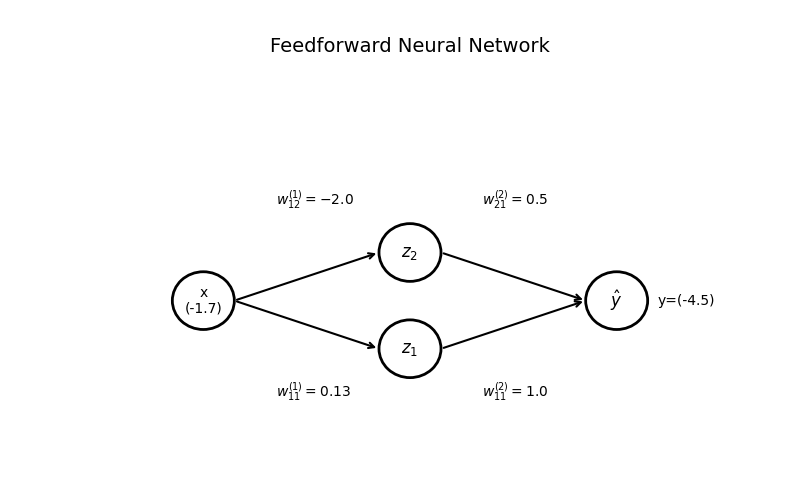

---
### 3.2: Facial keypoints detection with PyTorch FCN and CNN architectures

#### 3.2.1 Introduction
Facial keypoint detection is the task of identifying important landmarks on a human face (e.g., corners of the eyes, nose tip, mouth corners) in an image. These keypoints are crucial for many applications in computer vision:

- Aligning faces for recognition or verification.
- Tracking facial expressions for emotion detection.
- Applying augmented reality filters or effects accurately on a face.

In this exercise, we will build fully connected neural networks and convolutional neural networks to detect **15 keypoints** on **96x96 grayscale face images**. The network will take an image as input and output the $ (x,y) $ coordinates of the **15 facial keypoints**.

Source: [danielnouri.org](https://danielnouri.org/notes/2014/12/17/using-convolutional-neural-nets-to-detect-facial-keypoints-tutorial/)

### 3.2.2 Dataset overview

We will use the **Kaggle Facial Keypoints Detection** dataset ([Kaggle challenge webpage](https://www.kaggle.com/competitions/facial-keypoints-detection)). This dataset consists of a training set of **7,049** face images (96x96 pixels, grayscale). Each image has up to **15 keypoint coordinates** labeled (30 values: $ x $ and $ y $ for each of 15 facial landmarks). For example, the keypoints include the centers of the eyes, the tip of the nose, and the corners of the mouth.

#### Data format
The training data is provided as a CSV file (`training.csv`). Each row contains:

- **30 columns** of keypoint coordinates: `left_eye_center_x`, `left_eye_center_y`, `right_eye_center_x`, ... etc. (15 keypoints $\times$ 2). If a keypoint was not labeled for a given image, its value is missing.
- An **Image** column containing 96x96 pixel intensity values (9216 numbers) in a single string, separated by spaces.

If you downloaded this exercise from the Université Virtuelle, you should have a `training.csv` file in the `data/` directory. Now, let's load the training data using pandas and examine its structure.

#### Missing values
Not all images have all 15 keypoints annotated. In fact, only about 30% of the images have all 15 keypoints; the rest have some missing keypoint labels. Nearly all images have at least a few keypoints (e.g., eyes, nose, mouth) labeled, but many did not have the more peripheral points. In this tutorial, for simplicity, we will use only images with **complete keypoint data** (all 15 points). This means we'll discard images with any missing keypoint values. (In practice, one could use data augmentation or multi-stage training to leverage partially labeled images, but we will not cover that here.)

### 3.2.3 Exercise instructions

In this exercise, you should:
1. Explore the dataset
2. Preprocess the dataset to use it with neural networks including:
      - handling missing values
      - converting the image data from strings to numeric arrays
      - normalizing the pixel values
      - reshaping the images
      - preparing the keypoint coordinates labels
3. Implement a fully connected neural network and compute the validated MSE
4. Implement a convolutional neural network and compute the validated MSE
5. Visualize the predictions of both models with respect to the true keypoints coordinates on images